# Method comparison (homogenization, trend)

## Setup


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Paths
input_dir = Path("../input")
output_dir = Path("../output")
glambie_runs = input_dir / "glambie_runs_clean"
output_sensitivity = output_dir / "sensitivity"
output_sensitivity.mkdir(parents=True, exist_ok=True)

# Colors
colors_list = list(plt.colormaps["tab10"].colors)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors_list)


### Method label map


In [2]:
# Mapping for pretty labels (folder names may have "methods_" prefix and hyphens; we normalize on lookup)
method_label_map = {
    "regression_proportional": "Regression + proportional",
    "regression_seasonal_homogenization": "Regression + seasonal homogenization",
    "start_vs_end_proportional": "Start vs end + proportional",
    "start_vs_end_seasonal_homogenization": "Start vs end + seasonal homogenization",
}


def get_method_label(raw_label):
    key = raw_label.replace("-", "_")
    return method_label_map.get(key, method_label_map.get(key.removeprefix("methods_"), raw_label))


## Visualization of glambie runs


Regions (loop)


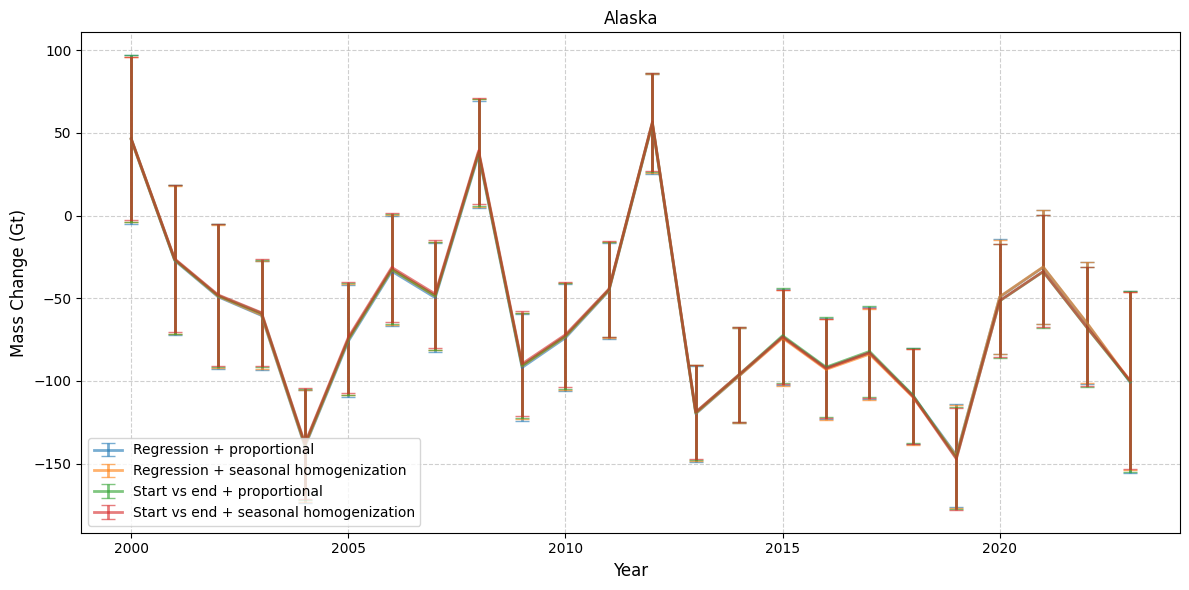

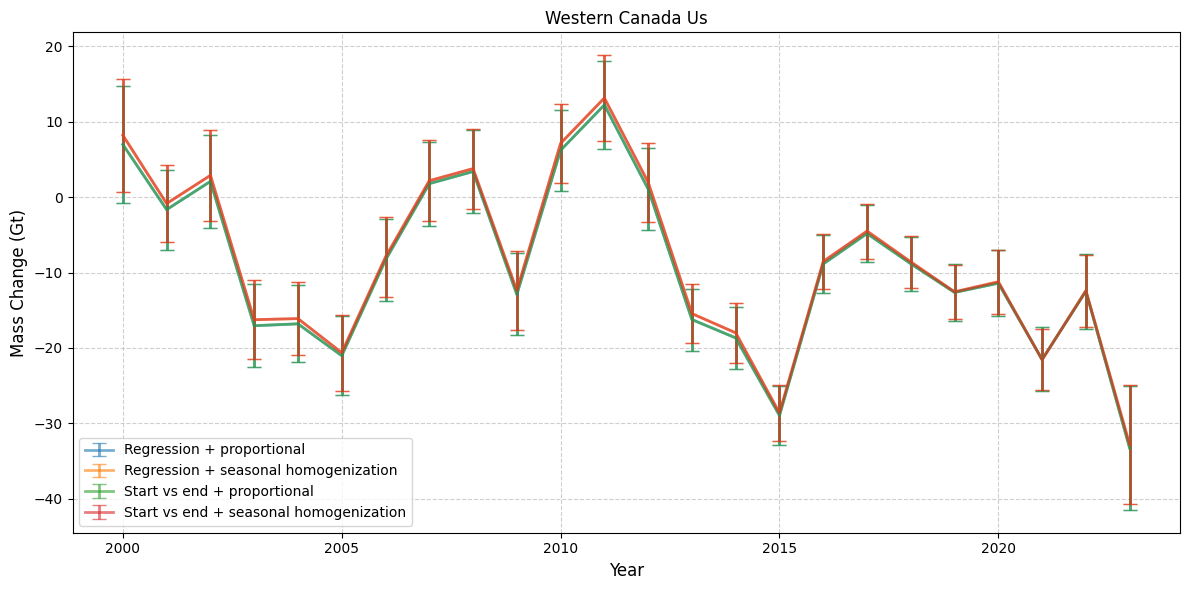

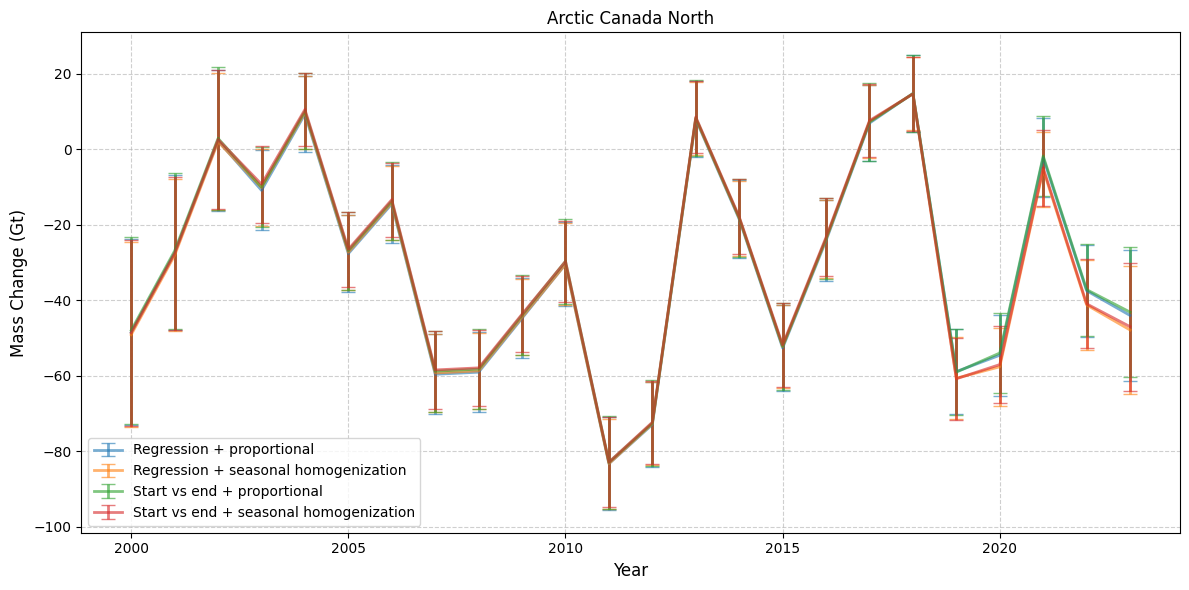

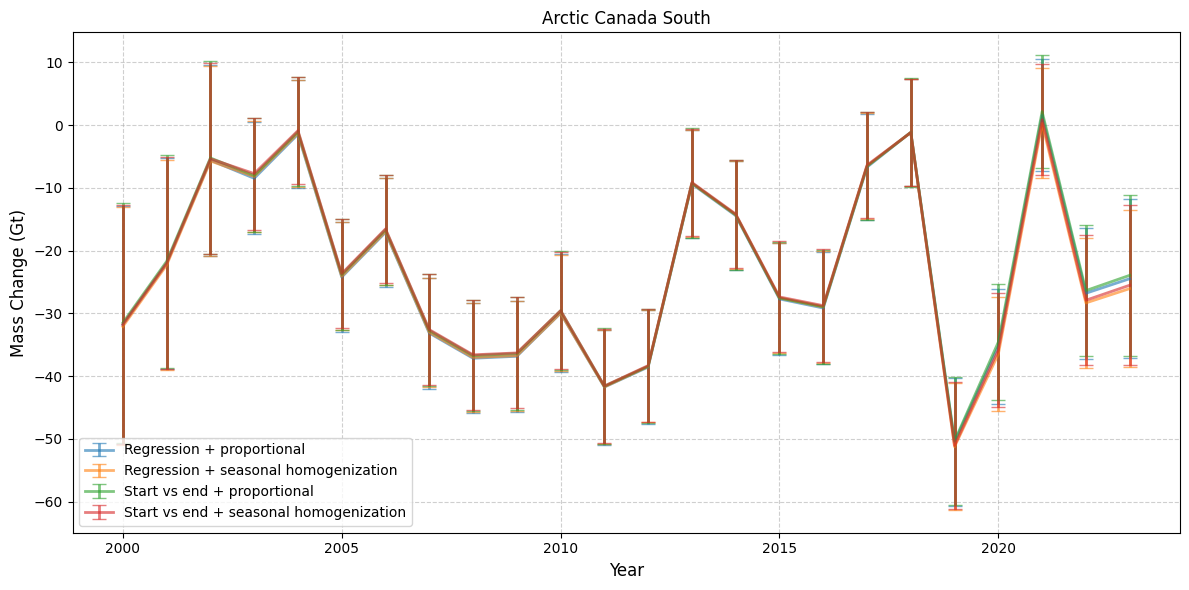

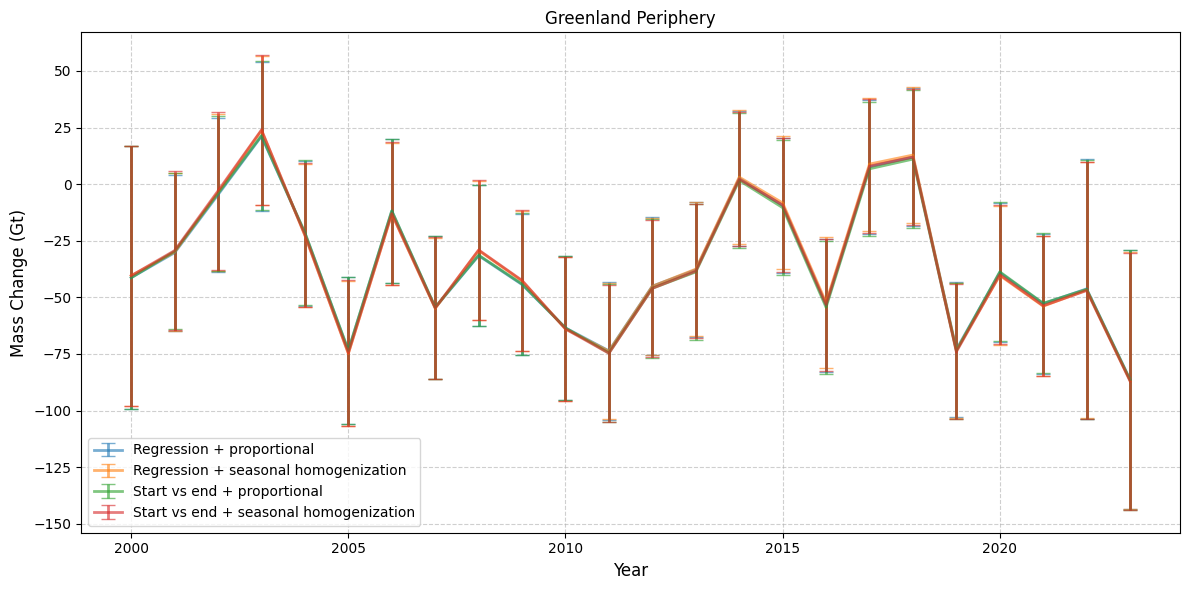

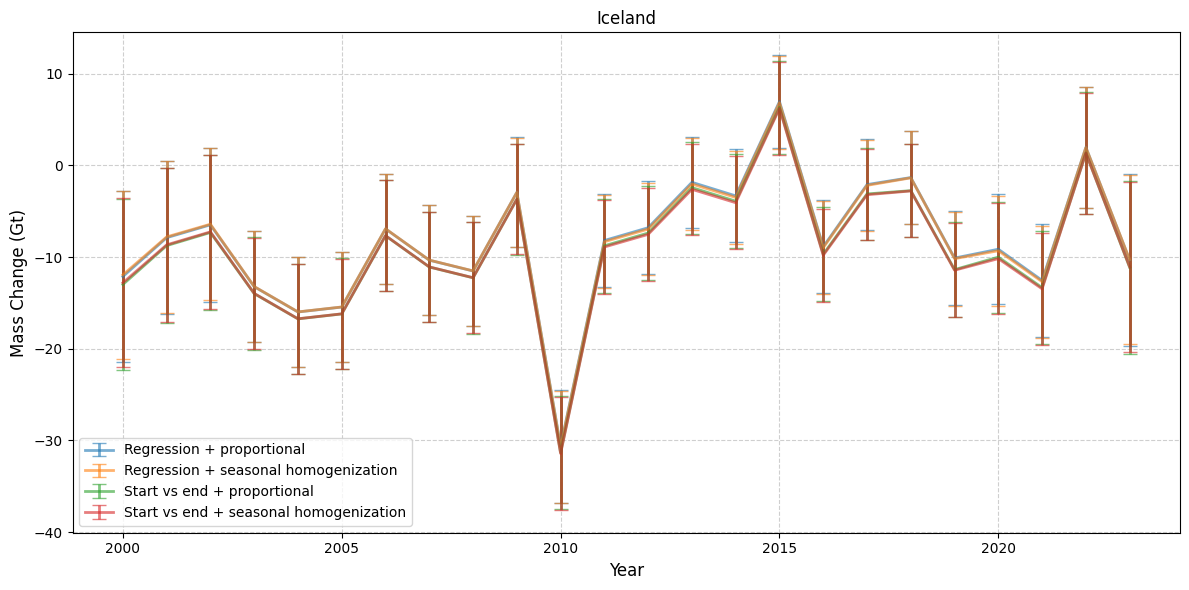

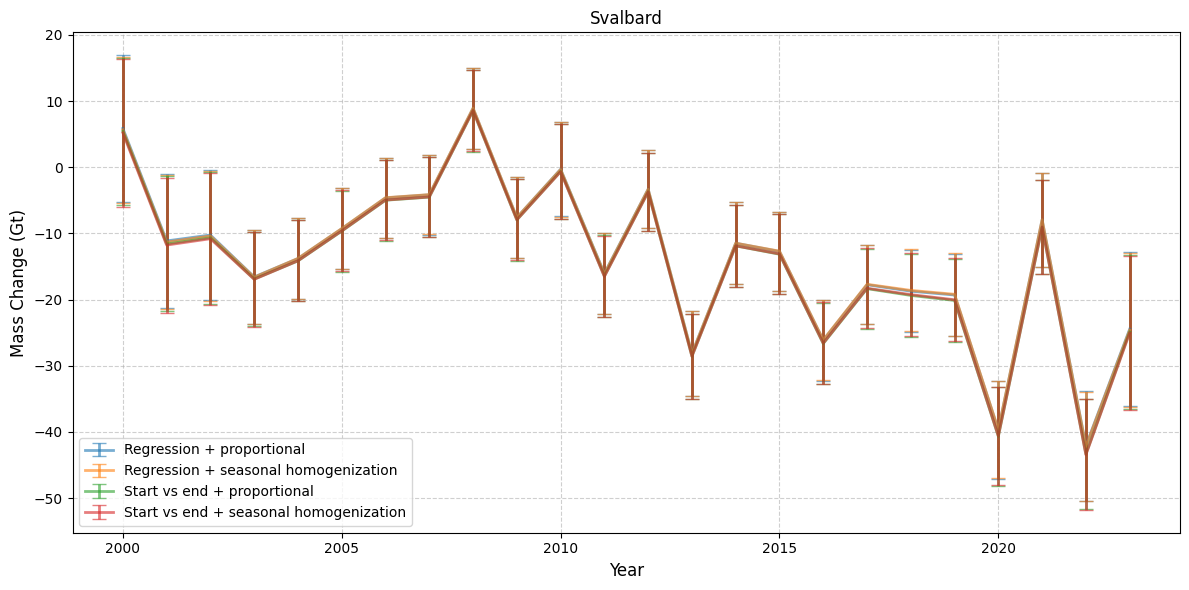

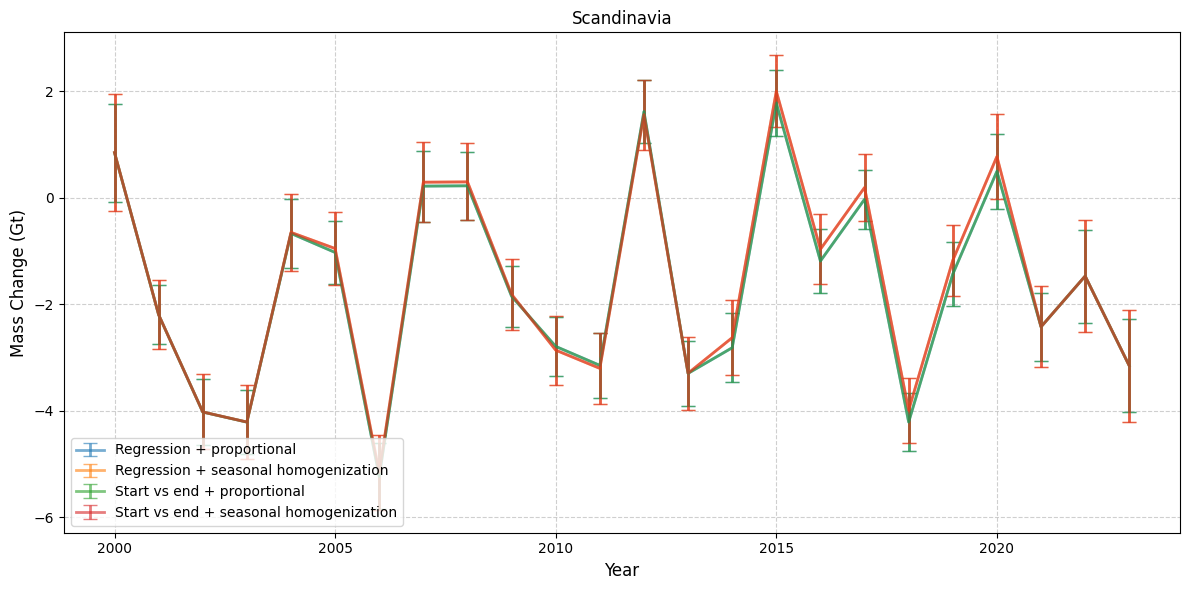

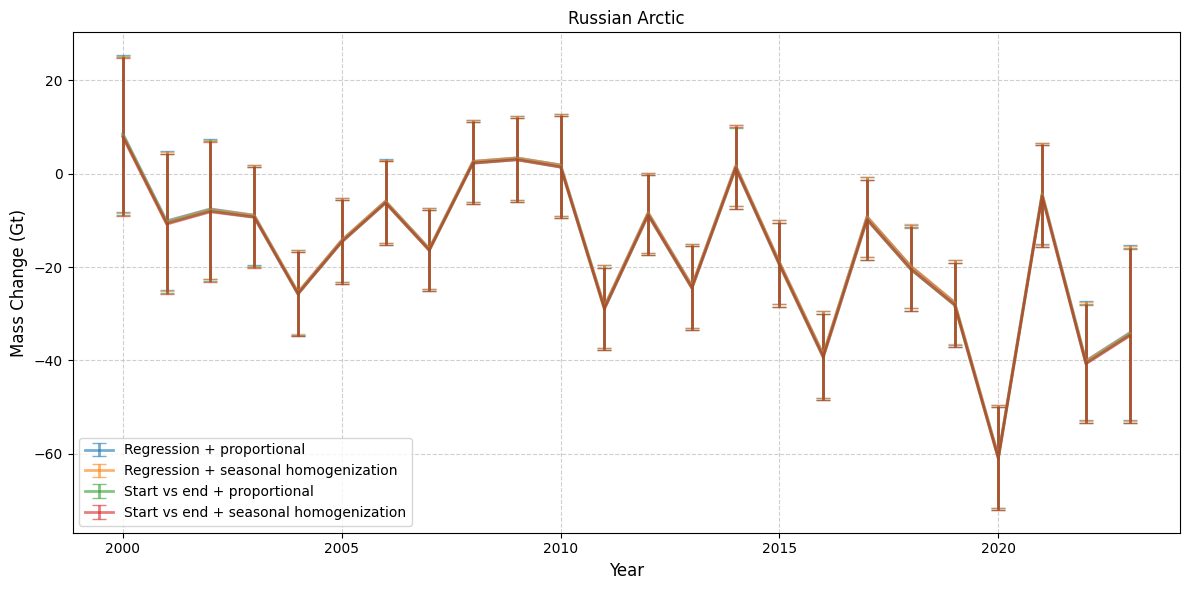

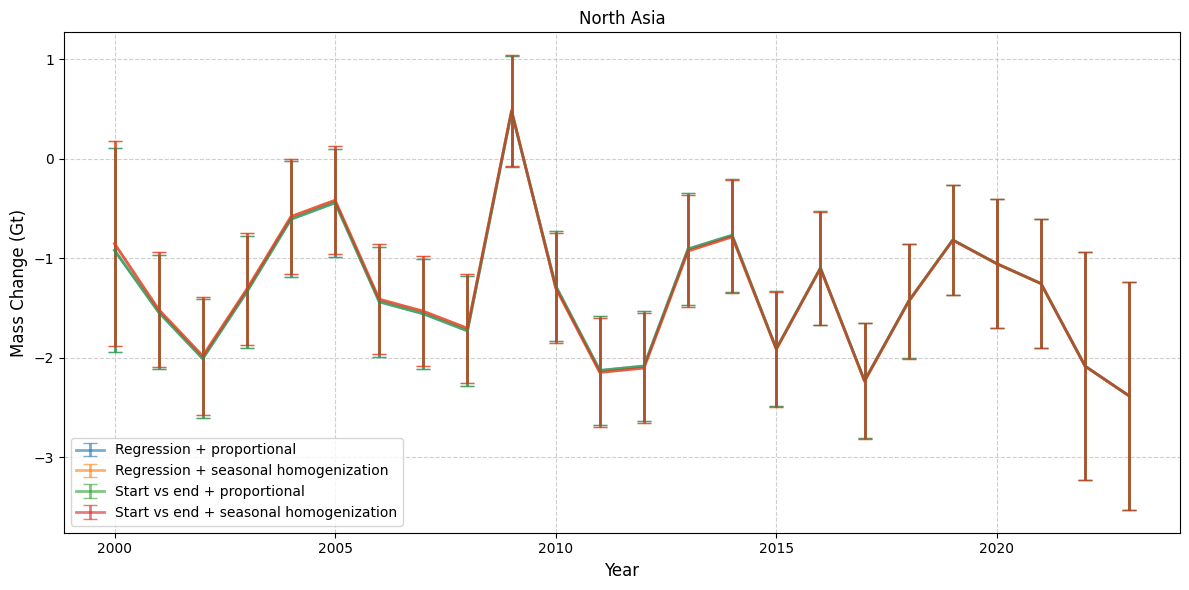

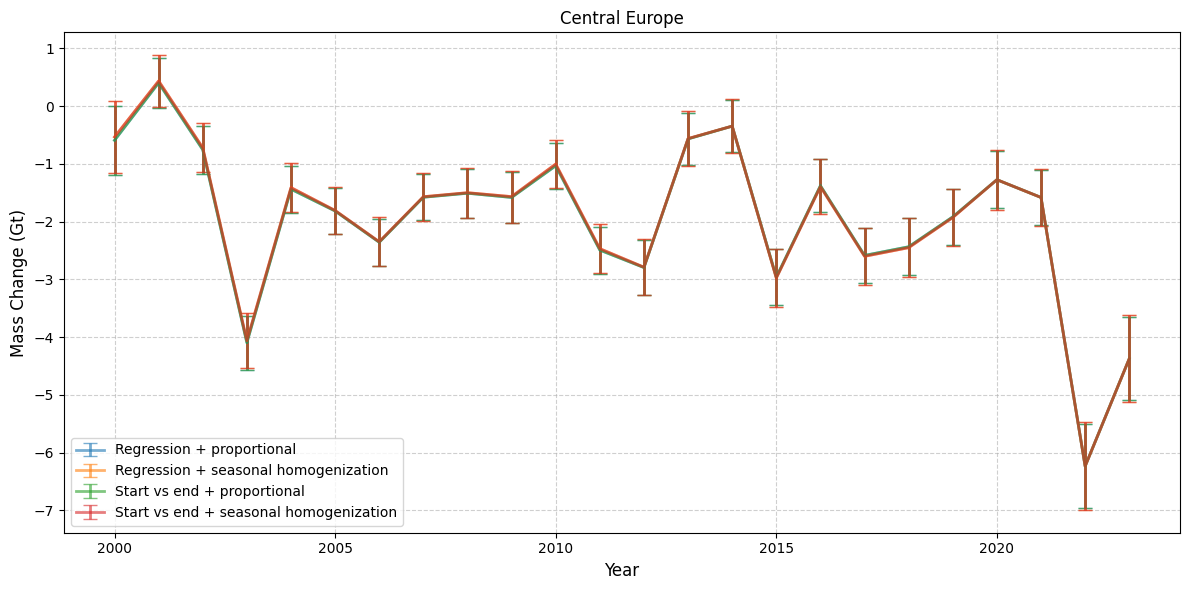

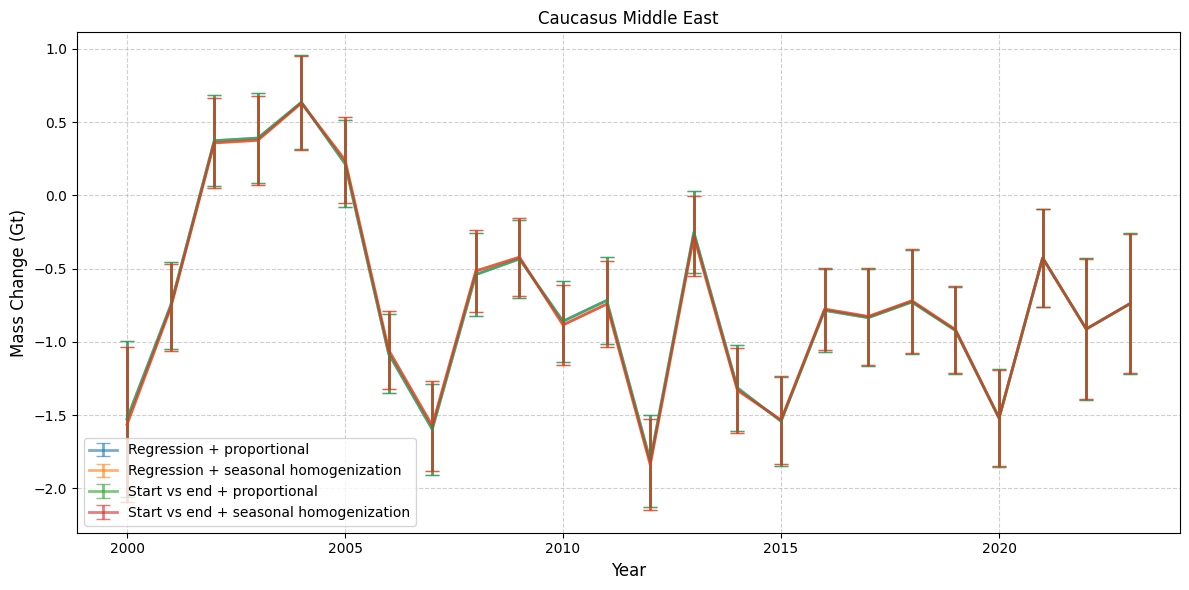

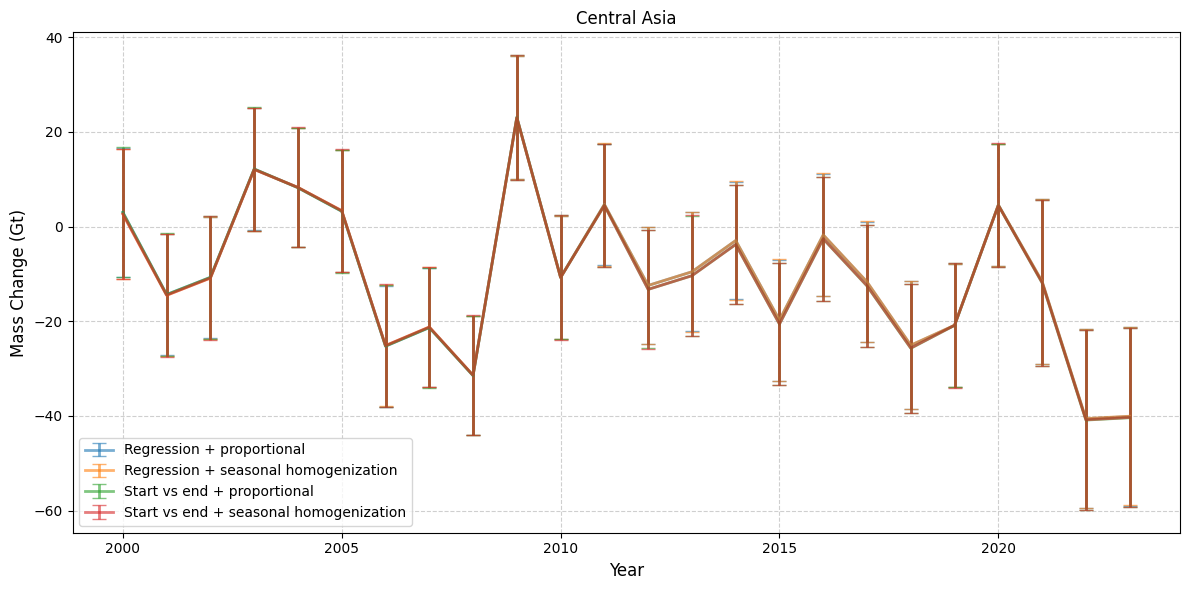

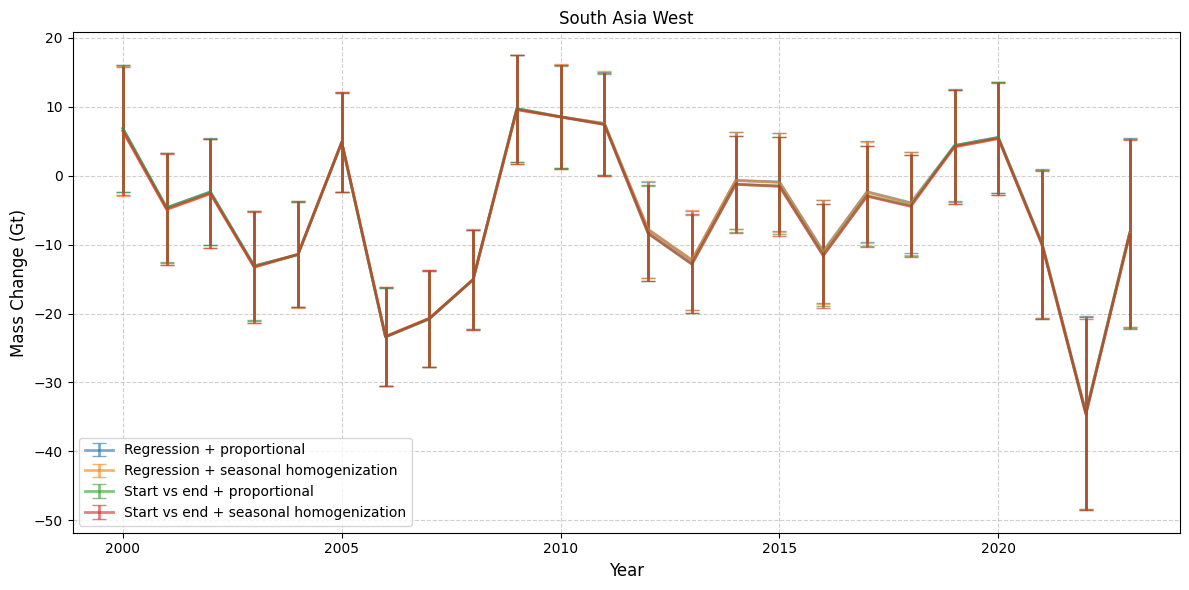

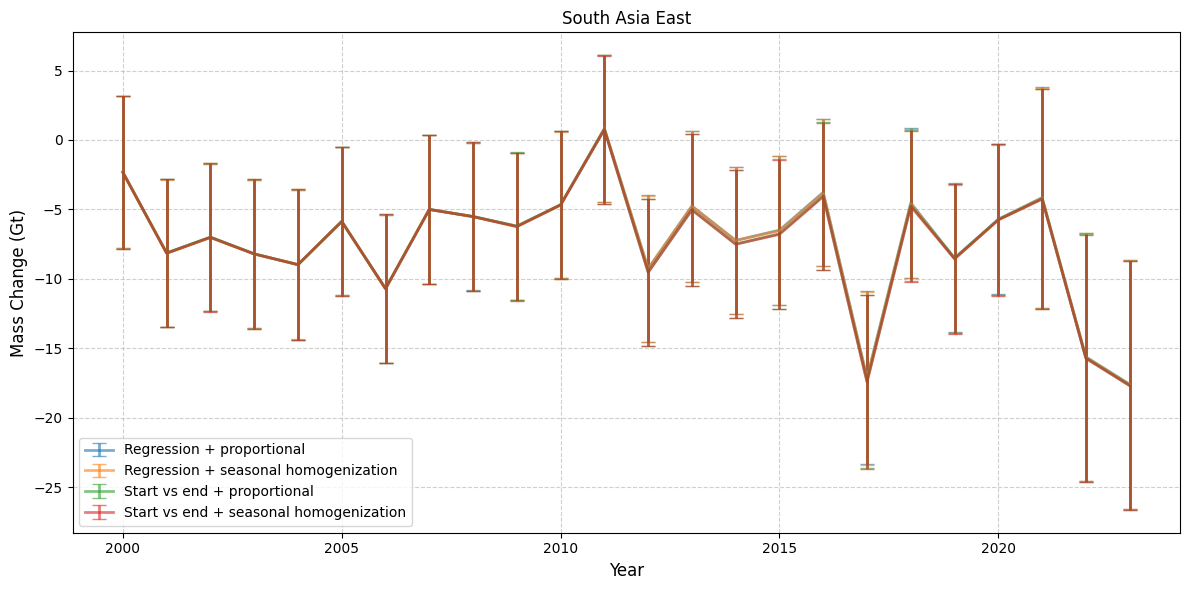

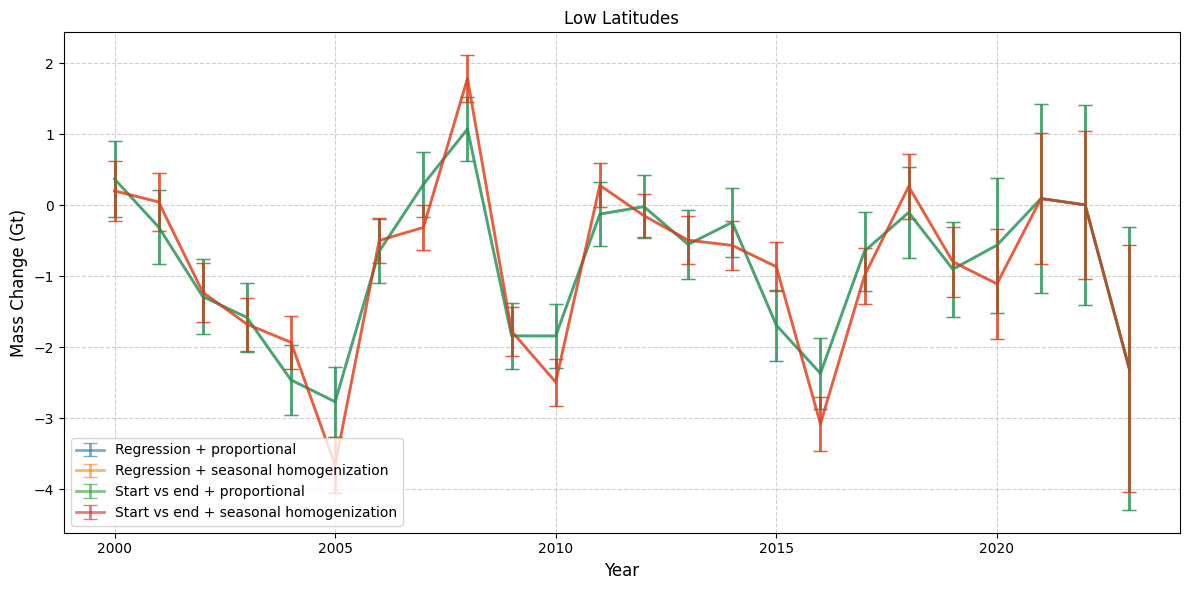

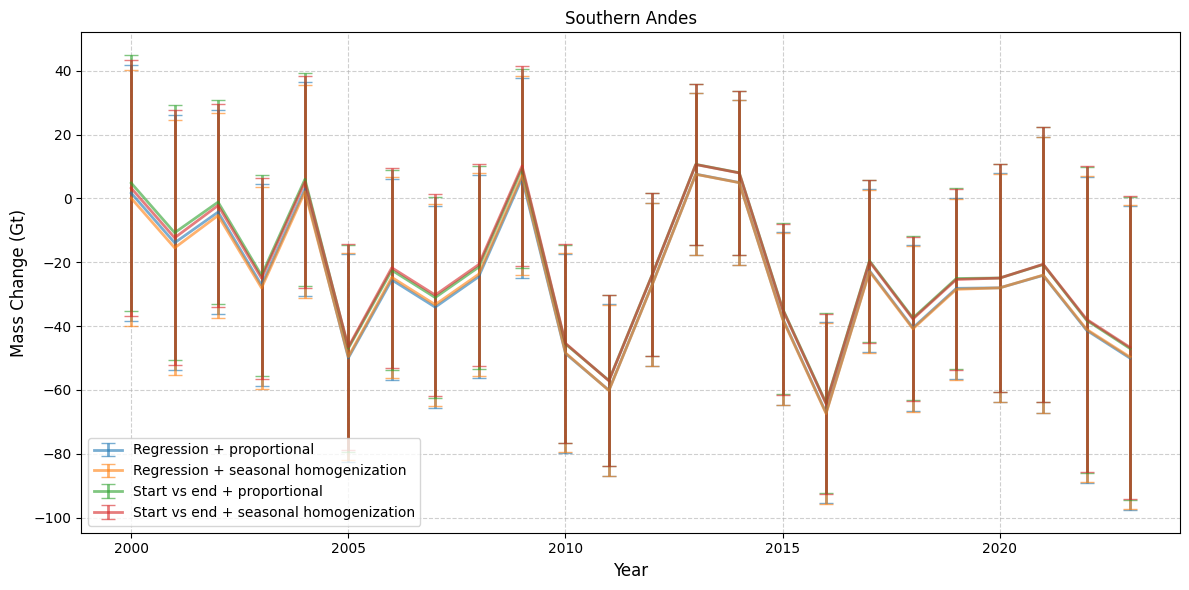

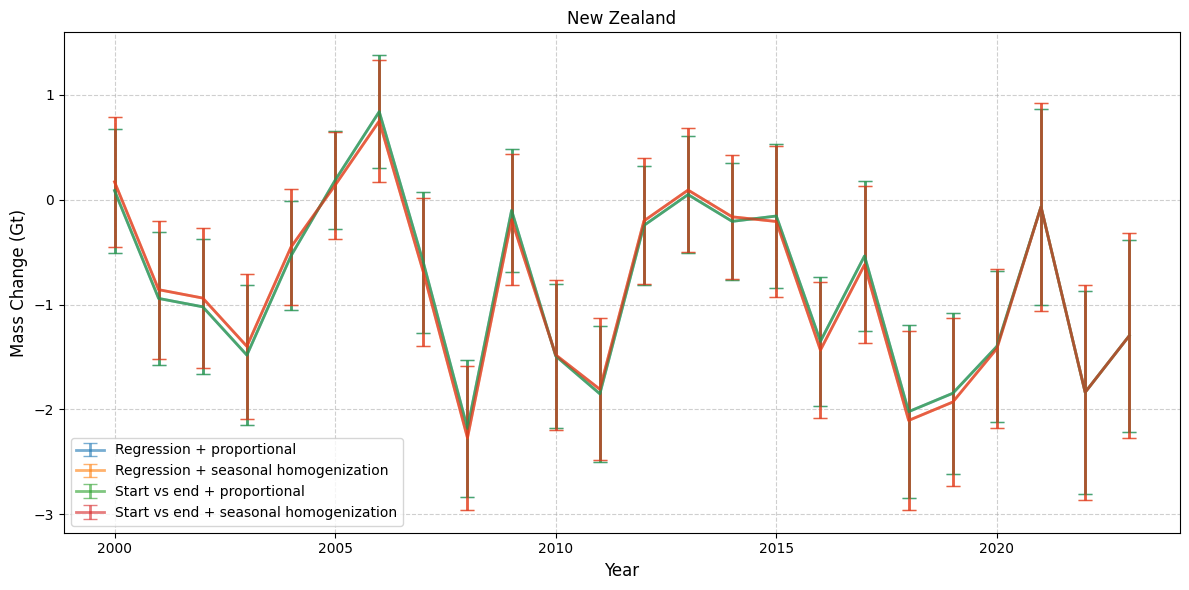

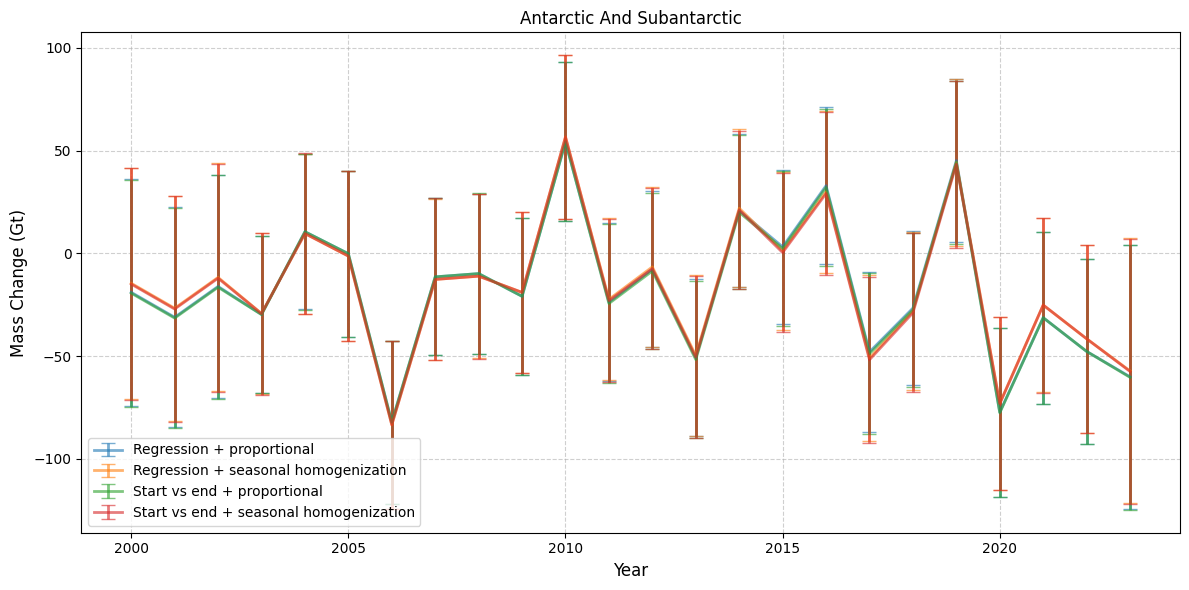

In [3]:
runs = sorted(p for p in glambie_runs.glob("methods*") if (p / "calendar_years").is_dir())
region_dirs_ordered = ["1_alaska", "2_western_canada_us", "3_arctic_canada_north", "4_arctic_canada_south", "5_greenland_periphery", "6_iceland", "7_svalbard", "8_scandinavia", "9_russian_arctic", "10_north_asia", "11_central_europe", "12_caucasus_middle_east", "13_central_asia", "14_south_asia_west", "15_south_asia_east", "16_low_latitudes", "17_southern_andes", "18_new_zealand", "19_antarctic_and_subantarctic"]

for region_idx in range(1, 20):
    region_dir = region_dirs_ordered[region_idx - 1]
    csv_files = sorted([run / "calendar_years" / f"{region_dir}.csv" for run in runs if (run / "calendar_years" / f"{region_dir}.csv").exists()])
    region_name = region_dir.split("_", 1)[1].replace("_", " ").title()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_prop_cycle(color=plt.colormaps["tab20"].colors)

    for file_idx, csv_file in enumerate(csv_files):
        df = pd.read_csv(str(csv_file))
        c = colors_list[file_idx % len(colors_list)]
        raw_label = csv_file.parent.parent.name
        label = get_method_label(raw_label)

        yerr = df["combined_gt_errors"] if "combined_gt_errors" in df.columns else None
        ax.errorbar(df["start_dates"], df["combined_gt"], yerr=yerr, color=c, linewidth=2, alpha=0.6, label=label, capsize=5)

    ax.set_title(region_name)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Mass Change (Gt)", fontsize=12)
    ax.legend(loc="lower left")
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.tight_layout()
    plt.show()

Global


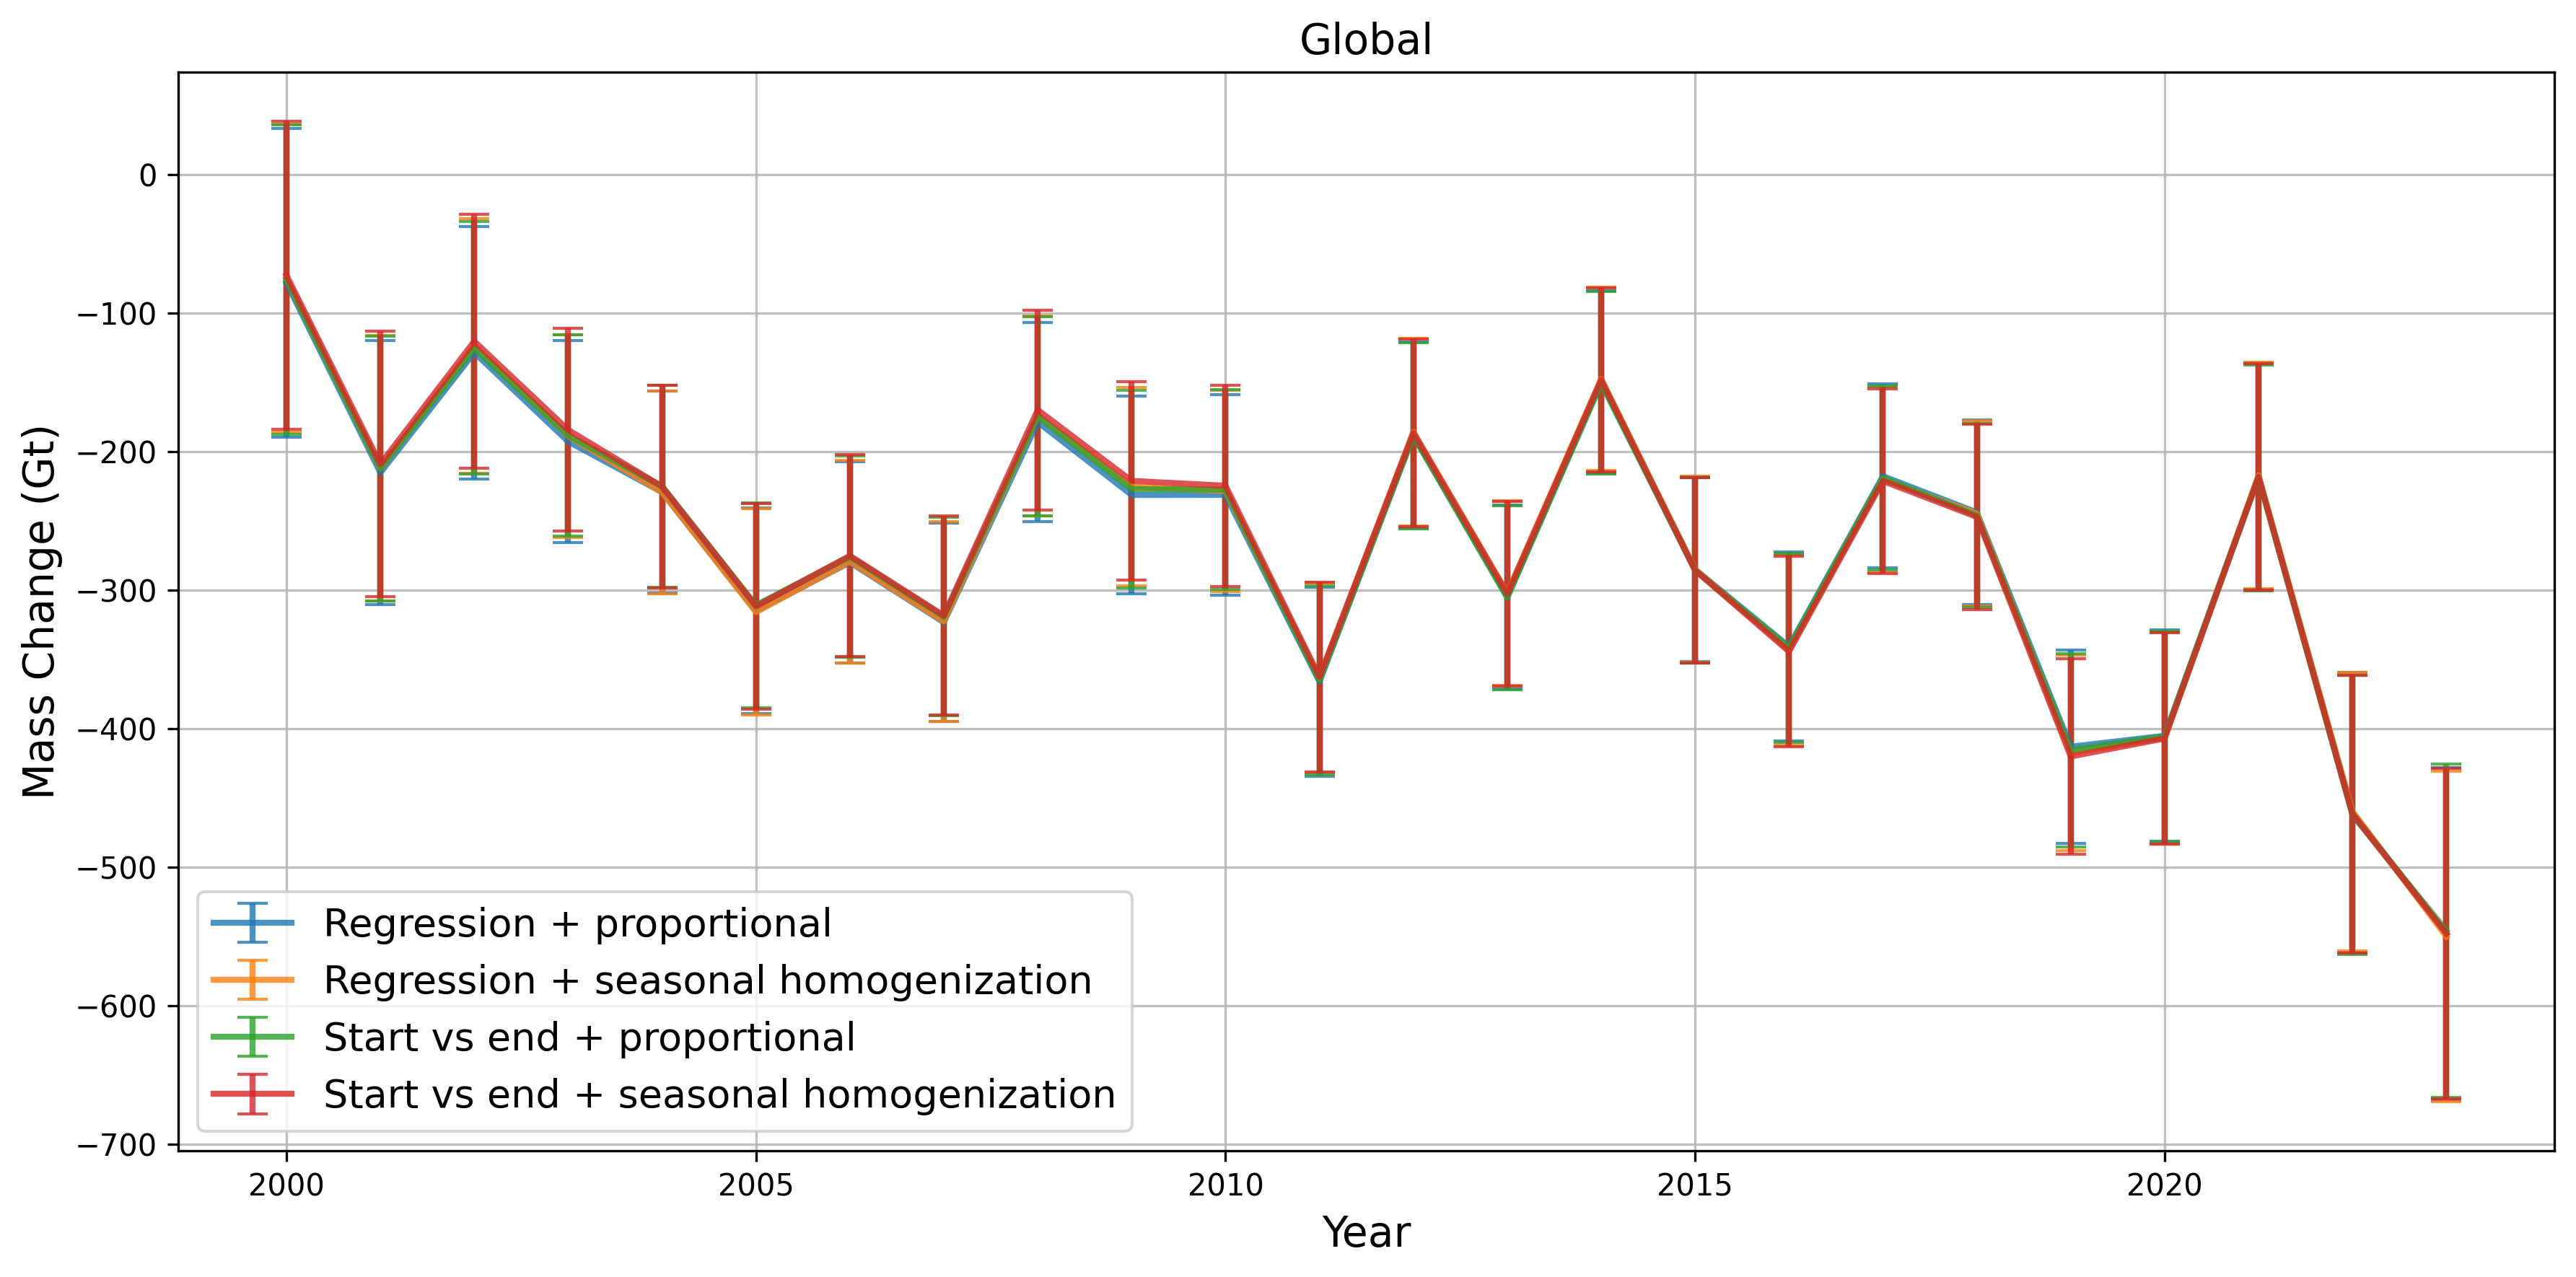

In [4]:
csv_files = sorted(glambie_runs.glob("methods_*/calendar_years/0_global.csv"))

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
colors_list = list(plt.colormaps["tab10"].colors)

for file_idx, csv_file in enumerate(csv_files):
    df = pd.read_csv(str(csv_file))
    c = colors_list[file_idx % len(colors_list)]
    raw_label = csv_file.parent.parent.name
    label = get_method_label(raw_label)

    yerr = df["combined_gt_errors"] if "combined_gt_errors" in df.columns else None
    ax.errorbar(df["start_dates"], df["combined_gt"], yerr=yerr, color=c, linewidth=2, alpha=0.8, label=label, capsize=5)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Mass Change (Gt)", fontsize=14)
ax.legend(loc="lower left", fontsize=13)
ax.set_title("Global", fontsize=14)
ax.grid(True, alpha=0.8)
fig.tight_layout()
plt.savefig(str(output_sensitivity / 'global_methods_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()


# Metrics

In [5]:
# Load initial glacier mass data
glacier_mass_file = input_dir / "glambie_reference" / "glacier_mass_2000.csv"
glacier_mass_df = pd.read_csv(str(glacier_mass_file), sep=";")
glacier_mass_dict = dict(zip(glacier_mass_df["Region"], glacier_mass_df["Mass"]))

# Add global initial mass from all regional masses
glacier_mass_dict["Global"] = float(glacier_mass_df["Mass"].sum())

print(f"Loaded initial mass for {len(glacier_mass_dict)} regions (including Global)")
glacier_mass_df.head()

Loaded initial mass for 20 regions (including Global)


,Region,Mass,Error,File
0,Alaska,16497,4190,1_alaska.csv
1,Western Canada and USA,950,243,2_western_canada_us.csv
2,Arctic Canada north,24105,6264,3_arctic_canada_north.csv
3,Arctic Canada south,7648,1981,4_arctic_canada_south.csv
4,Greenland periphery,12525,3249,5_greenland_periphery.csv


## Relative change of chamge

In [6]:
name_lookup = glacier_mass_df.set_index("File")["Region"]

runs = [p for p in glambie_runs.iterdir()
        if p.is_dir() and p.name.startswith("methods_") and (p / "calendar_years").is_dir()]

def print_metrics(files, ref="Regression + proportional"):
    # collect per-method stats
    methods = {}
    for f in files:
        df         = pd.read_csv(f)
        label      = get_method_label(f.parent.parent.name)
        cum_change = df["combined_gt"].sum()
        methods[label] = {
            "cum_change": cum_change,
            "ts":         df[["start_dates", "combined_gt"]],
        }

    # compare each method against reference
    ref_total = methods[ref]["cum_change"]
    rows = []
    for label in sorted(methods):
        method   = methods[label]
        abs_diff = method["cum_change"] - ref_total
        merged   = methods[ref]["ts"].merge(method["ts"], on="start_dates", suffixes=("_ref", "_cur"))
        rho      = float(spearmanr(merged["combined_gt_ref"], merged["combined_gt_cur"], nan_policy="omit")[0])
        rows.append({
            "run":             label,
            "Δ Cumul. Change (Gt)": abs_diff,
            "Δ Rel. Change (%)":    (abs_diff / abs(ref_total)) * 100,
            "spearman rho":    rho,
        })

    print(f"\n{name_lookup[files[0].name]}")
    print(pd.DataFrame(rows).to_string(index=False))

print_metrics(sorted(glambie_runs.glob("methods_*/calendar_years/0_global.csv")))
for fname in glacier_mass_df["File"].iloc[:-1]:
    region_dir = fname.replace(".csv", "")
    print_metrics([run / "calendar_years" / f"{region_dir}.csv" for run in runs])



Global
                                   run  Δ Cumul. Change (Gt)  Δ Rel. Change (%)  spearman rho
             Regression + proportional              0.000000           0.000000      1.000000
  Regression + seasonal homogenization             26.124883           0.399312      0.995652
           Start vs end + proportional             31.981047           0.488822      0.997391
Start vs end + seasonal homogenization             58.105930           0.888134      0.991304

Alaska
                                   run  Δ Cumul. Change (Gt)  Δ Rel. Change (%)  spearman rho
             Regression + proportional              0.000000           0.000000      1.000000
  Regression + seasonal homogenization              5.750965           0.390198      0.996522
           Start vs end + proportional              8.384474           0.568879      0.998261
Start vs end + seasonal homogenization             14.135439           0.959076      0.995652

Western Canada and USA
                    

## Relative change of total mass

In [7]:
mass_lookup = glacier_mass_df.set_index("File")["Mass"]
name_lookup = glacier_mass_df.set_index("File")["Region"]

def print_metrics(files, ref="Regression + proportional"):
    # collect per-method stats
    methods = {}
    for f in files:
        df           = pd.read_csv(f)
        label        = get_method_label(f.parent.parent.name)
        cum_change   = df["combined_gt"].sum()
        methods[label] = {
            "cum_change": cum_change,
            "rel_change": cum_change / mass_lookup[f.name] * 100,
            "ts":         df[["start_dates", "combined_gt"]],
        }

    # compare each method against reference
    rows = []
    for label in sorted(methods):
        method = methods[label]
        merged = methods[ref]["ts"].merge(method["ts"], on="start_dates", suffixes=("_ref", "_cur"))
        rho    = float(spearmanr(merged["combined_gt_ref"], merged["combined_gt_cur"], nan_policy="omit")[0])
        rows.append({
            "run":                  label,
            "Δ Cumul. Change (Gt)": method["cum_change"] - methods[ref]["cum_change"],
            "Δ Rel. Change (%)":    method["rel_change"] - methods[ref]["rel_change"],
            "spearman rho":         rho,
        })

    print(f"\n{name_lookup[files[0].name]}")
    print(pd.DataFrame(rows).to_string(index=False))

runs = [p for p in glambie_runs.iterdir()
        if p.is_dir() and p.name.startswith("methods_") and (p / "calendar_years").is_dir()]

print_metrics(sorted(glambie_runs.glob("methods_*/calendar_years/0_global.csv")))
for fname in glacier_mass_df["File"].iloc[:-1]:
    region_dir = fname.replace(".csv", "")
    print_metrics([run / "calendar_years" / f"{region_dir}.csv" for run in runs])



Global
                                   run  Δ Cumul. Change (Gt)  Δ Rel. Change (%)  spearman rho
             Regression + proportional              0.000000           0.000000      1.000000
  Regression + seasonal homogenization             26.124883           0.021462      0.995652
           Start vs end + proportional             31.981047           0.026273      0.997391
Start vs end + seasonal homogenization             58.105930           0.047734      0.991304

Alaska
                                   run  Δ Cumul. Change (Gt)  Δ Rel. Change (%)  spearman rho
             Regression + proportional              0.000000           0.000000      1.000000
  Regression + seasonal homogenization              5.750965           0.034861      0.996522
           Start vs end + proportional              8.384474           0.050824      0.998261
Start vs end + seasonal homogenization             14.135439           0.085685      0.995652

Western Canada and USA
                    